## 1. Imports, project paths and device

In [1]:
from pathlib import Path

import torch
import garmentiq as giq
from garmentiq.classification.model_definition import tinyViT
from garmentiq.segmentation.model_definition.birefnet import BiRefNet, load_birefnet_config
from garmentiq.landmark.detection.model_definition import PoseHighResolutionNet
from garmentiq.garment_classes import garment_classes
from garmentiq.landmark.derivation.derivation_dict import derivation_dict

ROOT = Path.cwd()

# Keep calibration-sheet photos separate: they are not garment inputs.
# This is a photo used only to test whether your four ArUco markers are detected correctly.
# The complete A3 calibration sheet
#All four ArUco markers: ID 0, 1, 2, 3
CALIBRATION_DIR = ROOT / "calibration_samples"
CALIBRATION_IMAGE = CALIBRATION_DIR / "ArUco_marker.jpeg"

# Put only photos containing BOTH a garment and the calibration sheet here.
INPUT_DIR = ROOT / "input_with_marker"
GARMENT_IMAGE = INPUT_DIR / "input_ArUco_marker.jpeg"
MODEL_DIR = ROOT / "models"
OUTPUT_DIR = ROOT / "outputs" / "trouser_measurements"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

assert CALIBRATION_IMAGE.exists(), f"Calibration image missing: {CALIBRATION_IMAGE}"
assert (MODEL_DIR / "tiny_vit_inditex_finetuned.pt").exists()
assert (MODEL_DIR / "birefnet" / "model.safetensors").exists()
assert (MODEL_DIR / "hrnet.pth").exists()

print("Using device:", DEVICE)
print("Calibration image:", CALIBRATION_IMAGE)
print("Garment image exists:", GARMENT_IMAGE.exists())

c:\Users\H.S.Thishon\OneDrive\Desktop\TrouserMeasure\GarmentIQ\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda
Calibration image: c:\Users\H.S.Thishon\OneDrive\Desktop\TrouserMeasure\GarmentIQ\calibration_samples\ArUco_marker.jpeg
Garment image exists: True


## 2. OpenCV / ArUco availability check

In [2]:
import cv2

print("OpenCV version:", cv2.__version__)
print("ArUco available:", hasattr(cv2, "aruco"))

OpenCV version: 5.0.0
ArUco available: True


## 3. Marker configuration

Set these to match your printed calibration sheet.

In [3]:
import cv2
import numpy as np

# Values for the printed A3 calibration sheet.
PLANE_WIDTH_MM = 260.0
PLANE_HEIGHT_MM = 380.0
MARKER_SIDE_MM = 50.0
ARUCO_DICT = cv2.aruco.DICT_4X4_50

# Physical top-left corner of each 50 mm marker on the 260 x 380 mm plane.
# Verify these 20 mm margins on the printed sheet before production use.
MARKER_TOP_LEFT_MM = {
    0: (44.0, 51.0),
    1: (207.0, 51.0),
    2: (207.0, 333.0),
    3: (44.0, 333.0),
}

## 4. ArUco detection function

Finds all four markers (IDs 0–3) and builds a homography that maps image pixels to millimetres on the sheet.

In [4]:
def get_pixel_to_mm_transform(image_path):
    """Map image pixels to millimetres using all four A3-sheet markers."""

    image_bgr = cv2.imread(str(image_path))
    if image_bgr is None:
        raise FileNotFoundError(f"Cannot read: {image_path}")

    dictionary = cv2.aruco.getPredefinedDictionary(ARUCO_DICT)
    parameters = cv2.aruco.DetectorParameters()
    detector = cv2.aruco.ArucoDetector(dictionary, parameters)

    corners, ids, rejected = detector.detectMarkers(image_bgr)

    if ids is None:
        raise ValueError("No ArUco markers detected in this image.")

    detected = {int(marker_id): corner.reshape(4, 2).astype(np.float32)
                for marker_id, corner in zip(ids.flatten(), corners)}
    required_ids = set(MARKER_TOP_LEFT_MM)
    missing_ids = sorted(required_ids - set(detected))
    if missing_ids:
        raise ValueError(f"Missing required marker IDs: {missing_ids}. Detected: {sorted(detected)}")

    image_points = []
    plane_points = []
    for marker_id, (x, y) in MARKER_TOP_LEFT_MM.items():
        # ArUco corner order is clockwise: top-left, top-right, bottom-right, bottom-left.
        image_points.extend(detected[marker_id])
        plane_points.extend([
            [x, y],
            [x + MARKER_SIDE_MM, y],
            [x + MARKER_SIDE_MM, y + MARKER_SIDE_MM],
            [x, y + MARKER_SIDE_MM],
        ])

    H, inliers = cv2.findHomography(
        np.asarray(image_points, dtype=np.float32),
        np.asarray(plane_points, dtype=np.float32),
        method=cv2.RANSAC,
    )
    if H is None:
        raise ValueError("Could not calculate the pixel-to-mm homography.")

    return H, detected, image_bgr

## 5. Marker visual validation

Draws the outline of every detected marker on `CALIBRATION_IMAGE` so you can confirm IDs 0–3 were found.

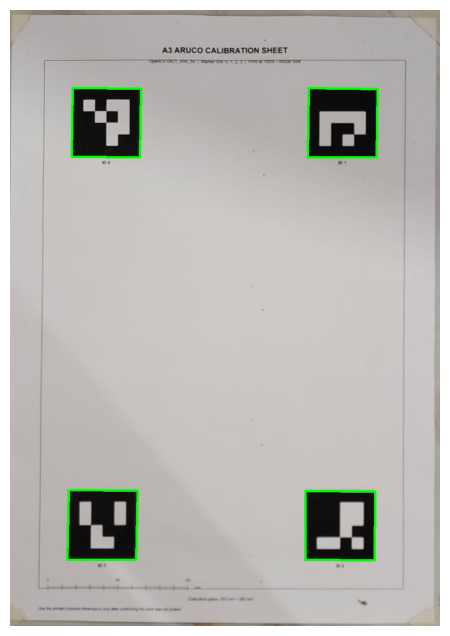

In [5]:
import matplotlib.pyplot as plt

H, marker_corners_by_id, image_bgr = get_pixel_to_mm_transform(CALIBRATION_IMAGE)

debug_image = image_bgr.copy()
cv2.polylines(
    debug_image,
    [corners.astype(int) for corners in marker_corners_by_id.values()],
    isClosed=True,
    color=(0, 255, 0),
    thickness=4,
)

plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(debug_image, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

## 6. Classification

In [6]:
classifier = giq.classification.load_model(
    model_path=str(MODEL_DIR / "tiny_vit_inditex_finetuned.pt"),
    model_class=tinyViT,
    model_args={"num_classes": 9, "img_size": (120, 184), "patch_size": 6},
    device=DEVICE,
)

assert GARMENT_IMAGE.exists(), f"Garment image missing: {GARMENT_IMAGE}"

label, probabilities = giq.classification.predict(
    model=classifier,
    image_path=str(GARMENT_IMAGE),
    classes=sorted(garment_classes),
    resize_dim=(120, 184),
    normalize_mean=[0.8047, 0.7808, 0.7769],
    normalize_std=[0.2957, 0.3077, 0.3081],
    device=DEVICE,
)

print(label, probabilities)

long sleeve top [0.005311162211000919, 0.779904842376709, 0.003403793554753065, 0.0818459540605545, 0.010272055864334106, 0.09667108952999115, 0.01882306858897209, 0.00039871016633696854, 0.00336941028945148]


The prediction above applies to the current `GARMENT_IMAGE`. Do not reuse an
earlier probability result after changing the image. Confirm that `label` is
`trousers` before continuing with the trouser landmark schema.

## 7. Segmentation

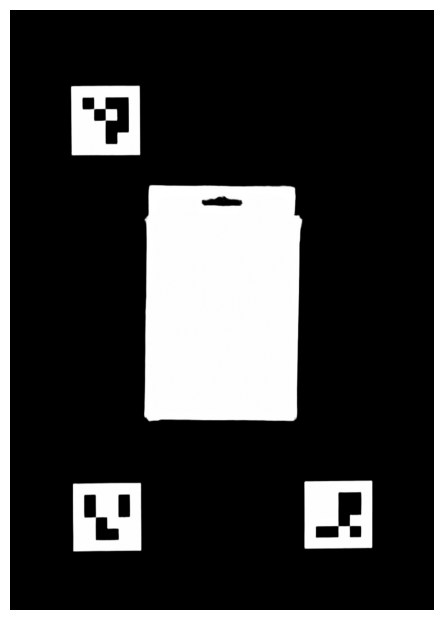

In [7]:
segmenter = giq.segmentation.load_model(
    model_path=str(MODEL_DIR / "birefnet" / "model.safetensors"),
    model_class=BiRefNet,
    model_args=load_birefnet_config(),
    device=DEVICE,
)

original, mask = giq.segmentation.extract(
    model=segmenter,
    image_path=str(GARMENT_IMAGE),
    resize_dim=(1024, 1024),
    normalize_mean=[0.485, 0.456, 0.406],
    normalize_std=[0.229, 0.224, 0.225],
    device=DEVICE,
)

giq.segmentation.plot(mask)

## 8. Landmark detection

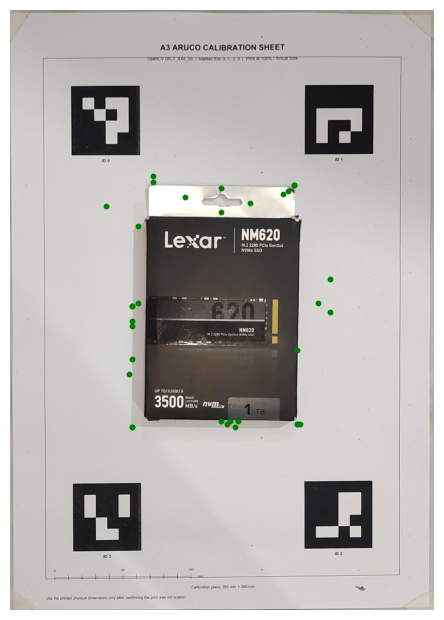

In [8]:
landmark_model = giq.landmark.detection.load_model(
    model_path=str(MODEL_DIR / "hrnet.pth"),
    model_class=PoseHighResolutionNet(),
    device=DEVICE,
)

coords, confidence, detection = giq.landmark.detect(
    class_name=label,  # or explicitly use "trousers" while testing trousers
    class_dict=garment_classes,
    image_path=str(GARMENT_IMAGE),
    model=landmark_model,
    scale_std=200.0,
    resize_dim=[288, 384],
    normalize_mean=[0.485, 0.456, 0.406],
    normalize_std=[0.229, 0.224, 0.225],
    device=DEVICE,
)

giq.landmark.plot(str(GARMENT_IMAGE), coordinate=coords, color="green")

## 9. Landmark refinement

Nudges each detected landmark onto the garment using the segmentation mask.

movement per point (dx, dy):
[[[-5.72916667  3.97916667]
  [-2.27083333  4.0625    ]
  [-5.22916667 -5.64583333]
  [-5.72916667 -5.35416667]
  [-5.14583333 -5.72916667]
  [-5.1875     -0.5625    ]
  [-5.60416667 -5.27083333]
  [-5.47916667 -5.39583333]
  [-5.47916667 -5.4375    ]
  [-5.9375     -5.14583333]
  [-5.47916667 -5.89583333]
  [-5.72916667 -5.8125    ]
  [-5.47916667 -5.6875    ]
  [-5.27083333 -5.85416667]
  [-5.5625     -5.14583333]
  [-5.5625     -5.0625    ]
  [-5.47916667 -5.6875    ]
  [-5.47916667 -5.47916667]
  [-5.47916667 -5.89583333]
  [-5.8125     -5.35416667]
  [-5.35416667 -5.35416667]
  [-5.77083333 -5.77083333]
  [-5.97916667 -5.8125    ]
  [-5.77083333 -5.8125    ]
  [-5.8125     -5.8125    ]
  [-5.4375     -5.89583333]
  [-5.27083333  4.52083333]
  [-5.35416667 -5.8125    ]
  [-5.8125     -5.35416667]
  [-5.10416667 -5.10416667]
  [-5.8125     -5.35416667]
  [-5.60416667 -5.14583333]
  [-5.27083333  4.52083333]]]


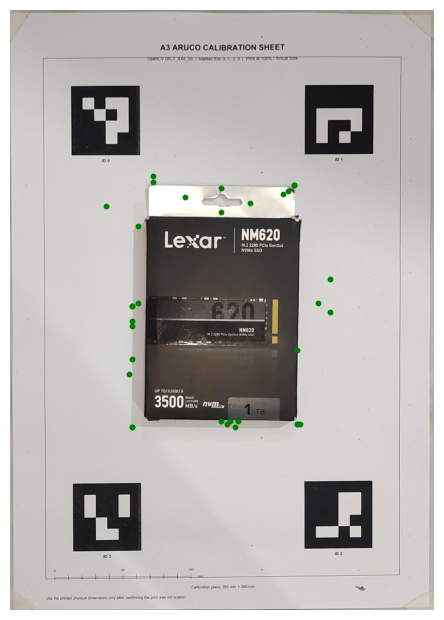

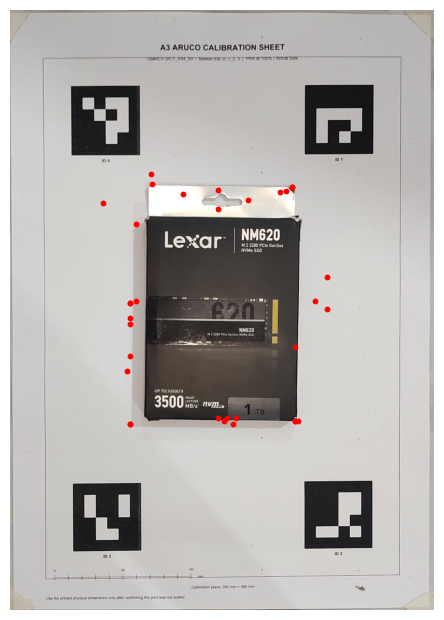

In [10]:
refined_coords, refined_detection = giq.landmark.refine(
    class_name=label,
    detection_np=coords,
    detection_conf=confidence,
    detection_dict=detection,
    mask=mask,
)

print("movement per point (dx, dy):")
print(refined_coords - coords)

giq.landmark.plot(GARMENT_IMAGE, coordinate=coords, color="green")         # before
giq.landmark.plot(GARMENT_IMAGE, coordinate=refined_coords, color="red")   # after



## 10. Pixel measurements

Derives any non-predefined landmarks, then computes each measurement as a straight-line distance in pixels.

In [11]:
derived, final_detection = giq.landmark.derive(
    class_name=label,
    detection_dict=refined_detection,
    derivation_dict=derivation_dict,
    landmark_coords=refined_coords,
    np_mask=mask,
)

pixel_measurements, final_detection = giq.utils.compute_measurement_distances(
    final_detection
)

print(pixel_measurements)

{'front length': 526.6695039432084, 'back width': 420.5436957083057, 'chest': 440.8106169320335, 'sleeve width': 20.298891169198434, 'sleeve length': 520.0346142325528}


## 11. Full tailor pipeline creation

Builds a `tailor` agent that runs every stage above on all images in `INPUT_DIR`.

In [12]:
tailor = giq.tailor(
    input_dir=str(INPUT_DIR),
    model_dir=str(MODEL_DIR),
    output_dir=str(OUTPUT_DIR),
    class_dict=garment_classes,
    do_derive=True,
    do_refine=True,
    classification_model_path="tiny_vit_inditex_finetuned.pt",
    classification_model_class=tinyViT,
    classification_model_args={
        "num_classes": 9,
        "img_size": (120, 184),
        "patch_size": 6,
        "resize_dim": (120, 184),
        "normalize_mean": [0.8047, 0.7808, 0.7769],
        "normalize_std": [0.2957, 0.3077, 0.3081],
    },
    segmentation_model_path="birefnet/model.safetensors",
    segmentation_model_class=BiRefNet,
    segmentation_model_args={
        "model_config": load_birefnet_config(),
        "resize_dim": (1024, 1024),
        "normalize_mean": [0.485, 0.456, 0.406],
        "normalize_std": [0.229, 0.224, 0.225],
    },
    landmark_detection_model_path="hrnet.pth",
    landmark_detection_model_class=PoseHighResolutionNet(),
    landmark_detection_model_args={
        "scale_std": 200.0,
        "resize_dim": [288, 384],
        "normalize_mean": [0.485, 0.456, 0.406],
        "normalize_std": [0.229, 0.224, 0.225],
    },
    derivation_dict=derivation_dict,
    device=DEVICE,
)

tailor.summary()

                              TAILOR AGENT SUMMARY                              
--------------------------------DIRECTORY PATHS---------------------------------
Input directory:          c:\Users\H.S.Thishon\OneDrive\Desktop\TrouserMeasure\GarmentIQ\input_with_marker
Model directory:          c:\Users\H.S.Thishon\OneDrive\Desktop\TrouserMeasure\GarmentIQ\models
Output directory:         c:\Users\H.S.Thishon\OneDrive\Desktop\TrouserMeasure\GarmentIQ\outputs\trouser_measurements

------------------------------------CLASSES-------------------------------------
Class Index | Class Name
----------- | ------------------------------------------------------------------
0           | long sleeve dress
1           | long sleeve top
2           | short sleeve dress
3           | short sleeve top
4           | shorts
5           | skirt
6           | trousers
7           | vest
8           | vest dress

------------------------------------OPTIONS-------------------------------------
Do refine?:  

## 12. Full tailor pipeline execution

Writes measurement JSON, masks and annotated images to `OUTPUT_DIR`.

In [13]:
garment_files = [
    path for pattern in ("*.jpg", "*.jpeg", "*.png", "*.bmp", "*.tiff")
    for path in INPUT_DIR.glob(pattern)
]
assert garment_files, (
    f"No garment photos found in {INPUT_DIR}. Add a photo containing both trousers and all four markers."
)

metadata, outputs = tailor.measure(
    save_segmentation_image=True,
    save_measurement_image=True,
)

Start measuring 1 garment images ...
There are 5 measurement steps: classification, segmentation, landmark detection,
landmark refinement, and landmark derivation.


Save measurement json: 100%|██████████| 1/1 [00:00<00:00, 111.45it/s]


## 13. mm conversion function

Converts landmark pixel coordinates to millimetres with the ArUco homography and recomputes each distance.

In [14]:
import json
import math
from pathlib import Path


def convert_measurement_json_to_mm(image_path, pixel_json_path, output_json_path):
    H, _, _ = get_pixel_to_mm_transform(image_path)

    pixel_result = json.loads(Path(pixel_json_path).read_text(encoding="utf-8"))

    image_name = next(iter(pixel_result))
    record = pixel_result[image_name]

    # Convert every detected landmark: (x_px, y_px) → (x_mm, y_mm)
    landmark_ids = list(record["landmarks"])
    pixel_points = np.array(
        [
            [
                record["landmarks"][landmark_id]["x"],
                record["landmarks"][landmark_id]["y"],
            ]
            for landmark_id in landmark_ids
        ],
        dtype=np.float32,
    )

    mm_points = cv2.perspectiveTransform(
        pixel_points.reshape(1, -1, 2),
        H,
    )[0]

    for landmark_id, (x_mm, y_mm) in zip(landmark_ids, mm_points):
        record["landmarks"][landmark_id]["x_mm"] = round(float(x_mm), 2)
        record["landmarks"][landmark_id]["y_mm"] = round(float(y_mm), 2)

    # Recalculate every measurement using transformed mm coordinates.
    for measurement in record["measurements"].values():
        start_id = measurement["landmarks"]["start"]
        end_id = measurement["landmarks"]["end"]

        start = record["landmarks"][start_id]
        end = record["landmarks"][end_id]

        distance_mm = math.hypot(
            end["x_mm"] - start["x_mm"],
            end["y_mm"] - start["y_mm"],
        )

        # Keep the original pixel result and add the physical result.
        measurement["distance_mm"] = round(distance_mm, 2)

    record["calibration"] = {
        "method": "ArUco planar homography",
        "marker_ids": sorted(MARKER_TOP_LEFT_MM),
        "marker_side_mm": MARKER_SIDE_MM,
        "plane_size_mm": [PLANE_WIDTH_MM, PLANE_HEIGHT_MM],
    }

    output_json_path = Path(output_json_path)
    output_json_path.parent.mkdir(parents=True, exist_ok=True)
    output_json_path.write_text(
        json.dumps(pixel_result, indent=2),
        encoding="utf-8",
    )

## 14. Generate final mm JSON files

In [15]:
MM_OUTPUT_DIR = OUTPUT_DIR / "measurement_mm_json"

for _, row in metadata.iterrows():
    image_path = INPUT_DIR / row["filename"]
    pixel_json_path = Path(row["measurement_json"])
    mm_json_path = MM_OUTPUT_DIR / pixel_json_path.name

    convert_measurement_json_to_mm(
        image_path=image_path,
        pixel_json_path=pixel_json_path,
        output_json_path=mm_json_path,
    )

print("Saved calibrated JSON files to:", MM_OUTPUT_DIR)

Saved calibrated JSON files to: c:\Users\H.S.Thishon\OneDrive\Desktop\TrouserMeasure\GarmentIQ\outputs\trouser_measurements\measurement_mm_json
